## 📦 Imports & Global Settings

In [ ]:
import os, glob, hashlib, random
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import seaborn as sns

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# Configuration: preprocessing window, training parameters, early stopping
cfg = dict(win_size=256, step=128, seq_len=8,
           batch=32, epochs=20, lr=1e-3,
           early_stop=3)

# Define model checkpoint path
BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()
CHECKPOINT_DIR = os.path.abspath(os.path.join(BASE_DIR, "..", "checkpoints"))
MODEL_PATH     = os.path.join(CHECKPOINT_DIR, "model.pth")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

## 📁 Dataset Class with On-Disk Caching

Converts raw CSV data into fixed-size tensor sequences and caches the results to avoid redundant processing during re-training.

In [ ]:
class CachedCurrentDataset(Dataset):
    """
    Custom Dataset that converts raw CSV signals into (seq_len, C, win_size) tensors.
    Caches preprocessed samples to disk for faster reuse.
    """
    def __init__(self, files, win_size=256, step=128, seq_len=8,
                 per_sample_norm=True, cache_dir="cache"):
        self.per_sample_norm = per_sample_norm
        self.win_size, self.seq_len = win_size, seq_len

        os.makedirs(cache_dir, exist_ok=True)
        key   = "|".join(sorted(files)) + f"{win_size}_{step}_{seq_len}"
        cache = os.path.join(cache_dir, hashlib.md5(key.encode()).hexdigest()+".pth")

        # Load cached data if available
        if os.path.exists(cache):
            self.samples = torch.load(cache, map_location="cpu")
            print(f"[Cache] loaded {len(self.samples)} samples from {cache}")
            return

        # Otherwise, build and cache dataset
        self.samples = []
        for fp in tqdm(files, desc="building index"):
            cur, label = self._load_raw(fp)  # cur: (C, N)
            wins = [cur[:, s:s+win_size]
                    for s in range(0, cur.shape[1]-win_size+1, step)]
            for i in range(0, len(wins)-seq_len+1):
                seq = np.stack(wins[i:i+seq_len])  # (S, C, W)
                self.samples.append(
                    (torch.tensor(seq, dtype=torch.float32), label))
        torch.save(self.samples, cache)
        print(f"[Cache] indexed {len(self.samples)} samples → {cache}")

    @staticmethod
    def _load_raw(fp):
        # Load raw signal data and label from CSV
        data  = pd.read_csv(fp, skiprows=9, usecols=[1,2,3],
                            header=None).to_numpy().T  # (3, N)
        label = int(pd.read_csv(fp, skiprows=3, nrows=1,
                                header=None)[1].iloc[0])
        return data, label

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        # Normalize sample if enabled
        x, y = self.samples[idx]
        if self.per_sample_norm:
            mean = x.mean(dim=(0,2), keepdim=True)
            std  = x.std (dim=(0,2), keepdim=True) + 1e-6
            x = (x - mean) / std
        return x, torch.tensor(y, dtype=torch.long)


## 📂 Load Train/Test File Lists

In [ ]:
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor
import pickle, glob, os
from tqdm.auto import tqdm                         
from sklearn.model_selection import train_test_split

# train_dir = os.path.join("..", "data", "train")
# test_dir  = os.path.join("..", "data", "test")
train_dir = r"E:\datasets\deep_learning\data\train"
test_dir  = r"E:\datasets\deep_learning\data\test"

train_all  = glob.glob(os.path.join(train_dir, "**", "*.csv"), recursive=True)
test_files = glob.glob(os.path.join(test_dir,  "**", "*.csv"), recursive=True)
print(f"found {len(train_all)} train  |  {len(test_files)} test")

# Check paths of the first 10 files
for i, fp in enumerate(train_all[:10]):
    print(f"{i+1}. {fp} - 존재: {os.path.exists(fp)}")

# Check contents of the first file
try:
    with open(train_all[0]) as f:
        print(f"첫 번째 파일 내용 일부:\n{f.read(200)}")  # print first 200 characters only
except Exception as e:
    print(f"파일 읽기 실패: {e}")


found 207022 train  |  25904 test
1. E:\datasets\deep_learning\data\train\current\11kW\L-CAHU-01R\정상\STFCB-20200928-0105-0109_20201222_105207_002.csv - 존재: True
2. E:\datasets\deep_learning\data\train\current\11kW\L-CAHU-01R\정상\STFCB-20200928-0105-0109_20201222_105307_002.csv - 존재: True
3. E:\datasets\deep_learning\data\train\current\11kW\L-CAHU-01R\정상\STFCB-20200928-0105-0109_20201222_105405_002.csv - 존재: True
4. E:\datasets\deep_learning\data\train\current\11kW\L-CAHU-01R\정상\STFCB-20200928-0105-0109_20201222_105406_002.csv - 존재: True
5. E:\datasets\deep_learning\data\train\current\11kW\L-CAHU-01R\정상\STFCB-20200928-0105-0109_20201222_105407_002.csv - 존재: True
6. E:\datasets\deep_learning\data\train\current\11kW\L-CAHU-01R\정상\STFCB-20200928-0105-0109_20201222_105505_002.csv - 존재: True
7. E:\datasets\deep_learning\data\train\current\11kW\L-CAHU-01R\정상\STFCB-20200928-0105-0109_20201222_105507_002.csv - 존재: True
8. E:\datasets\deep_learning\data\train\current\11kW\L-CAHU-01R\정상\STFCB-2020

## 🏷️ Label Caching

In [32]:
from tqdm import tqdm
import hashlib
from pathlib import Path
import pickle
import time
from collections import Counter

# 라벨 캐시 파일 경로
CACHE_META = Path("labels.pkl")

# 캐시 파일이 이미 존재하는 경우 로드
if CACHE_META.exists():
    with CACHE_META.open("rb") as f:
        file2label = pickle.load(f)
    print(f"[Label-Cache] 기존 캐시에서 {len(file2label)} 파일의 라벨 정보 로드 완료")

else:
    def quick_label(fp: str) -> int:
        """4번째 줄(인덱스 3)에 있는 라벨 정수값만 읽어 온다."""
        with open(fp) as f:
            for _ in range(3):
                f.readline()
            return int(f.readline().split(",")[1])

    print(f"[FULL] 처리할 파일 수: {len(train_all)}")
    file2label = {}

    # 중간 저장 기능 추가 (만약의 경우를 대비)
    batch_size = 10000
    start_time = time.time()

    for i in range(0, len(train_all), batch_size):
        batch = train_all[i:i+batch_size]
        print(f"\n배치 {i//batch_size + 1}/{(len(train_all)-1)//batch_size + 1} 시작 ({len(batch)} 파일)")
        
        for fp in tqdm(batch, desc=f"배치 {i//batch_size + 1} 처리 중"):
            try:
                label = quick_label(fp)
                file2label[fp] = label
            except Exception as e:
                print(f"오류 발생 - 파일: {os.path.basename(fp)}, 에러: {e}")
        
        # 각 배치마다 중간 결과 저장
        elapsed = time.time() - start_time
        processed = len(file2label)
        remaining = len(train_all) - processed
        est_time = elapsed / processed * remaining if processed > 0 else 0
        
        print(f"\n진행 상태: {processed}/{len(train_all)} 파일 완료 ({processed/len(train_all)*100:.1f}%)")
        print(f"경과 시간: {elapsed/60:.1f}분, 예상 남은 시간: {est_time/60:.1f}분")
        print(f"라벨 분포: {dict(Counter(file2label.values()))}")
        
        # 중간 캐시 저장
        with open(f"labels_partial_{processed}.pkl", "wb") as f:
            pickle.dump(file2label, f)
        print(f"중간 캐시 저장 완료: labels_partial_{processed}.pkl")

    # 최종 캐시 저장
    with open(CACHE_META, "wb") as f:
        pickle.dump(file2label, f)
    print(f"[FULL] 캐시 저장 완료: {CACHE_META}")

# 라벨 분포 출력 (캐시를 로드한 경우에도 확인 가능)
print(f"\n라벨 분포: {dict(Counter(file2label.values()))}")

[Label-Cache] 기존 캐시에서 207022 파일의 라벨 정보 로드 완료

라벨 분포: {0: 52875, 3: 41187, 2: 32559, 4: 26669, 1: 53732}


## ✂️ Train/Validation Split

In [33]:
# 라벨 캐싱 완료 후 
labels_pool = [file2label[p] for p in train_all]

# train/val 분할
train_files, val_files = train_test_split(
    train_all,
    test_size=0.10,
    random_state=42,
    stratify=labels_pool)

print(f"split → train {len(train_files)} | val {len(val_files)} | test {len(test_files)}")

# 6. Training loop 부분의 수정
num_classes = len(np.unique(list(file2label.values())))

split → train 186319 | val 20703 | test 25904


## 🧾 Dataset & DataLoader Setup

In [ ]:
train_ds = CachedCurrentDataset(train_files,
                                cfg["win_size"], cfg["step"], cfg["seq_len"])
val_ds   = CachedCurrentDataset(val_files,

                                cfg["win_size"], cfg["step"], cfg["seq_len"])
test_ds  = CachedCurrentDataset(test_files,
                                cfg["win_size"], cfg["step"], cfg["seq_len"])
loader_opts = dict(batch_size=cfg["batch"],
                   num_workers=0,
                   pin_memory=(torch.cuda.is_available()))
train_ld = DataLoader(train_ds, shuffle=True,  **loader_opts)
val_ld   = DataLoader(val_ds,   shuffle=False, **loader_opts)
test_ld  = DataLoader(test_ds,  shuffle=False, **loader_opts)

C:\Users\awear\AppData\Local\Temp\ipykernel_44472\1589657711.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.samples = torch.load(cache, map_location="cpu")


[Cache] loaded 1304233 samples from cache\fdd09efb1f7425cc52a8def67482235e.pth
[Cache] loaded 144921 samples from cache\9b3d457e2e24c5041c48d50cc9a9df25.pth
[Cache] loaded 181328 samples from cache\958f34163c04f0ec6390d3fde7fcfeea.pth


## 🧠 CNN-LSTM Model Definition


Combines CNN for spatial feature extraction and LSTM for sequence modeling.

In [ ]:
class CNN_LSTM(nn.Module):
    # Hybrid model combining CNN for feature extraction and LSTM for temporal modeling
    def __init__(self, cnn_out=32, lstm_hidden=64, num_classes=4):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(3,16,7,padding=3), nn.BatchNorm1d(16), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16,32,5,padding=2), nn.BatchNorm1d(32), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.AdaptiveAvgPool1d(1))
        
        self.lstm = nn.LSTM(cnn_out, lstm_hidden, 2,
                            batch_first=True, dropout=0.3)
        
        self.fc = nn.Sequential(
            nn.Linear(lstm_hidden,64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes))

    def forward(self, x):
        # x: (batch, seq_len, channels, window_size)
        b,s,c,w = x.size()
        feat = self.cnn(x.view(b*s,c,w)).squeeze(-1)     # (b*s, cnn_out)
        lstm_out,_ = self.lstm(feat.view(b,s,-1))
        return self.fc(lstm_out[:,-1])                   # Use last time step

## 🔁 Training & Evaluation Utilities

Functions that perform a single epoch of training or evaluation.

In [ ]:
# One training pass over the dataset (single epoch)
def train_epoch(model, loader, crit, optim, dev):
    model.train(); loss_sum, corr, tot = 0,0,0
    for x,y in loader:
        x,y = x.to(dev), y.to(dev)
        optim.zero_grad()
        out  = model(x)
        loss = crit(out,y); loss.backward(); optim.step()
        loss_sum += loss.item()
        pred = out.argmax(1); tot += y.size(0); corr += pred.eq(y).sum().item()
    return loss_sum/len(loader), corr/tot

# Evaluation loop without gradient updates
@torch.no_grad()
def eval_epoch(model, loader, crit, dev):
    model.eval(); loss_sum, corr, tot = 0,0,0
    for x,y in loader:
        x,y = x.to(dev), y.to(dev)
        out  = model(x)
        loss = crit(out,y); loss_sum += loss.item()
        pred = out.argmax(1); tot += y.size(0); corr += pred.eq(y).sum().item()
    return loss_sum/len(loader), corr/tot

## 🚀 Training Loop
Full training process over multiple epochs, including training, validation, model checkpointing, learning rate scheduling, and early stopping.

In [ ]:
print("\n" + "="*50)
print("학습 시작")
print("="*50)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"클래스 수: {num_classes}, 디바이스: {device}")

# First batch loading test (optional)
try:
    print("\n첫 번째 배치 로딩 테스트...")
    test_x, test_y = next(iter(train_ld))
    print(f"배치 형태: {test_x.shape}, 레이블: {test_y.shape}")
    print(f"메모리 사용량: {test_x.element_size() * test_x.nelement() / (1024*1024):.2f} MB")
    print("데이터 로딩 테스트 완료!\n")
except Exception as e:
    print(f"데이터 로딩 오류: {e}")

def train_with_progress():
    model = CNN_LSTM(num_classes=num_classes).to(device)
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"모델: {model.__class__.__name__}")
    print(f"총 파라미터: {total_params:,}")
    print(f"학습 가능 파라미터: {trainable_params:,}")
    
    # Set loss function, optimizer, and scheduler
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2, verbose=True
    )
    
    # Initialize training variables
    best_val, patience = float('inf'), 0
    hist_train, hist_val = [], []
    start_time = time.time()
    
    # Result output table header
    print(f"\n{'Epoch':^6}|{'Train Loss':^10}|{'Train Acc':^10}|{'Val Loss':^10}|{'Val Acc':^10}|{'Time':^8}|{'LR':^7}|{'Best':^6}")
    print(f"{'-'*6}|{'-'*10}|{'-'*10}|{'-'*10}|{'-'*10}|{'-'*8}|{'-'*7}|{'-'*6}")
    
    # Epoch loop
    for epoch in range(1, cfg["epochs"]+1):
        epoch_start = time.time()
        
        # Training loop
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        # Iterate batches with progress bar
        train_bar = tqdm(train_ld, desc=f"Epoch {epoch}/{cfg['epochs']} [Train]")
        for batch_idx, (x, y) in enumerate(train_bar):
            # Move data to device
            x, y = x.to(device), y.to(device)
            
            # Forward & backward pass
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            
            # Update statistics
            train_loss += loss.item()
            pred = outputs.argmax(1)
            train_total += y.size(0)
            train_correct += pred.eq(y).sum().item()
            
            # Update progress bar
            avg_loss = train_loss / (batch_idx + 1)
            avg_acc = 100. * train_correct / train_total if train_total > 0 else 0
            train_bar.set_postfix(loss=f"{avg_loss:.4f}", acc=f"{avg_acc:.2f}%")
            
            # Optionally clear gradients periodically to save memory
            if batch_idx % 100 == 0 and batch_idx > 0:
                torch.cuda.empty_cache()
        
        # Calculate epoch averages
        train_loss /= len(train_ld)
        train_acc = train_correct / train_total
        
        # Validation loop
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        
        with torch.no_grad():
            val_bar = tqdm(val_ld, desc=f"Epoch {epoch}/{cfg['epochs']} [Val]")
            for batch_idx, (x, y) in enumerate(val_bar):
                x, y = x.to(device), y.to(device)
                
                # Forward pass only
                outputs = model(x)
                loss = criterion(outputs, y)
                
                # Update statistics
                val_loss += loss.item()
                pred = outputs.argmax(1)
                val_total += y.size(0)
                val_correct += pred.eq(y).sum().item()
                
                # Update progress bar
                avg_loss = val_loss / (batch_idx + 1)
                avg_acc = 100. * val_correct / val_total if val_total > 0 else 0
                val_bar.set_postfix(loss=f"{avg_loss:.4f}", acc=f"{avg_acc:.2f}%")
        
        # Calculate epoch averages
        val_loss /= len(val_ld)
        val_acc = val_correct / val_total
        
        # Save results
        hist_train.append((train_loss, train_acc))
        hist_val.append((val_loss, val_acc))
        
        # Update learning rate scheduler
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Calculate epoch time
        epoch_time = time.time() - epoch_start
        
        # Save best performing model
        is_best = val_loss < best_val
        best_marker = "*" if is_best else ""
        
        if is_best:
            best_val = val_loss
            patience = 0
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_loss': train_loss,
                'val_loss': val_loss,
                'train_acc': train_acc,
                'val_acc': val_acc,
                'num_classes': num_classes,
                'config': cfg
            }
            torch.save(checkpoint, MODEL_PATH)
            print(f"최고 성능 모델 저장: {MODEL_PATH}")
        else:
            patience += 1
        
        # Print epoch results
        print(f"{epoch:^6}|{train_loss:^10.4f}|{train_acc:^10.2%}|{val_loss:^10.4f}|{val_acc:^10.2%}|{epoch_time:^8.1f}s|{current_lr:^7.6f}|{best_marker:^6}")
        
        # Early stopping check
        if patience >= cfg["early_stop"]:
            print(f"조기 종료! (에폭 {epoch})")
            break
    
    # Calculate total training time
    total_time = time.time() - start_time
    hours, remainder = divmod(total_time, 3600)
    minutes, seconds = divmod(remainder, 60)
    print(f"총 학습 시간: {int(hours):02d}:{int(minutes):02d}:{int(seconds):02d}")
    
    return hist_train, hist_val, model

try:
    print(f"학습 시작: 훈련 샘플 {len(train_ds):,}개, 검증 샘플 {len(val_ds):,}개")
    hist_train, hist_val, trained_model = train_with_progress()
    print("학습 완료!")
    
    # Load the best model from checkpoint (for testing)
    best_checkpoint = torch.load(MODEL_PATH, map_location=device)
    best_epoch = best_checkpoint['epoch'] if isinstance(best_checkpoint, dict) and 'epoch' in best_checkpoint else 'unknown'
    print(f"최적 모델 (에폭 {best_epoch})이 {MODEL_PATH}에 저장됨")
    
except Exception as e:
    import traceback
    print(f"학습 중 오류 발생: {e}")
    traceback.print_exc()


학습 시작
클래스 수: 5, 디바이스: cuda

첫 번째 배치 로딩 테스트...
배치 형태: torch.Size([32, 8, 3, 256]), 레이블: torch.Size([32])
메모리 사용량: 0.75 MB
데이터 로딩 테스트 완료!

학습 시작: 훈련 샘플 1,304,233개, 검증 샘플 144,921개


c:\Users\awear\miniconda3\envs\torch_env\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


모델: CNN_LSTM
총 파라미터: 65,893
학습 가능 파라미터: 65,893

Epoch |Train Loss|Train Acc | Val Loss | Val Acc  |  Time  |  LR   | Best 
------|----------|----------|----------|----------|--------|-------|------


Epoch 1/20 [Val]: 100%|██████████| 4529/4529 [01:02<00:00, 72.05it/s, acc=92.93%, loss=0.1577] 


최고 성능 모델 저장: c:\Users\awear\my_projects\deep_learning\checkpoints\model.pth
  1   |  0.2524  |  89.29%  |  0.1577  |  92.93%  | 1467.3 s|0.001000|  *   


...

  15  |  0.0830  |  96.64%  |  0.0794  |  96.58%  | 1423.1 s|0.001000|      


Epoch 16/20 [Val]: 100%|██████████| 4529/4529 [00:59<00:00, 76.15it/s, acc=96.86%, loss=0.0791] 


  16  |  0.0804  |  96.71%  |  0.0791  |  96.86%  | 1428.3 s|0.001000|      


Epoch 17/20 [Val]: 100%|██████████| 4529/4529 [00:43<00:00, 103.06it/s, acc=96.80%, loss=0.0780]
C:\Users\awear\AppData\Local\Temp\ipykernel_44472\4048350274.py:171: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues r

  17  |  0.0812  |  96.74%  |  0.0780  |  96.80%  | 1411.0 s|0.000500|      
조기 종료! (에폭 17)
총 학습 시간: 06:44:51
학습 완료!
최적 모델 (에폭 14)이 c:\Users\awear\my_projects\deep_learning\checkpoints\model.pth에 저장됨


## ✅ Final Evaluation on Test Set

In [ ]:
print("\n" + "="*50)
print("테스트 평가 시작")
print("="*50)

test_model = CNN_LSTM(num_classes=num_classes).to(device)

# Handle new checkpoint format (if saved as a dict)
try:
    checkpoint = torch.load(MODEL_PATH, map_location=device)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        test_model.load_state_dict(checkpoint['model_state_dict'])
        print(f"체크포인트(에폭 {checkpoint['epoch']})에서 모델 가중치 로드 완료")
    else:
        test_model.load_state_dict(checkpoint)
        print("이전 형식의 체크포인트에서 모델 가중치 로드 완료")
except Exception as e:
    print(f"모델 로드 중 오류 발생: {e}")
    print("테스트를 진행할 수 없습니다.")
    import sys
    sys.exit(1)

# Run test
test_model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    test_bar = tqdm(test_ld, desc="테스트 진행 중")
    for x, y in test_bar:
        x = x.to(device)
        
        # Prediction
        outputs = test_model(x)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        
        # Collect results
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())
        all_probs.extend(probs.cpu().numpy())
        
        # Update progress bar
        correct = preds.cpu().eq(y).sum().item()
        total = y.size(0)
        test_bar.set_postfix(acc=f"{100.0 * correct / total:.2f}%")

# Convert results to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Calculate evaluation metrics
test_acc = accuracy_score(all_labels, all_preds)

print("\n" + "="*50)
print(f"테스트 정확도: {test_acc:.4f}")
print("="*50)
print("\n분류 보고서:")
print(classification_report(all_labels, all_preds, digits=4))

# Calculate confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("\n혼동 행렬:")
print(cm)

# Additional metrics
from sklearn.metrics import f1_score, precision_score, recall_score

f1 = f1_score(all_labels, all_preds, average='weighted')
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')

print(f"\n추가 메트릭:")
print(f"F1 점수 (가중치): {f1:.4f}")
print(f"정밀도 (가중치): {precision:.4f}")
print(f"재현율 (가중치): {recall:.4f}")

# Per-class metrics (optional)
class_names = [f"Class {i}" for i in range(num_classes)]
print("\n클래스별 정확도:")
for i in range(num_classes):
    class_mask = all_labels == i
    if np.sum(class_mask) > 0:
        class_acc = accuracy_score(all_labels[class_mask], all_preds[class_mask])
        print(f"{class_names[i]}: {class_acc:.4f} ({np.sum(class_mask)} 샘플)")

C:\Users\awear\AppData\Local\Temp\ipykernel_44472\1051384424.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MODEL_PATH, map_location=device)



테스트 평가 시작
체크포인트(에폭 14)에서 모델 가중치 로드 완료


테스트 진행 중: 100%|██████████| 5667/5667 [01:47<00:00, 52.84it/s, acc=100.00%]



테스트 정확도: 0.8843

분류 보고서:
              precision    recall  f1-score   support

           0     0.7886    0.7486    0.7681     46368
           1     0.9797    0.9997    0.9896     47040
           2     0.8072    0.9982    0.8926     28504
           3     0.9971    0.7596    0.8623     36064
           4     0.8563    0.9749    0.9117     23352

    accuracy                         0.8843    181328
   macro avg     0.8858    0.8962    0.8849    181328
weighted avg     0.8913    0.8843    0.8824    181328


혼동 행렬:
[[34712   974  6796    66  3820]
 [    0 47025     0    14     1]
 [   52     0 28452     0     0]
 [ 8668     0     0 27396     0]
 [  586     0     1     0 22765]]

추가 메트릭:
F1 점수 (가중치): 0.8824
정밀도 (가중치): 0.8913
재현율 (가중치): 0.8843

클래스별 정확도:
Class 0: 0.7486 (46368 샘플)
Class 1: 0.9997 (47040 샘플)
Class 2: 0.9982 (28504 샘플)
Class 3: 0.7596 (36064 샘플)
Class 4: 0.9749 (23352 샘플)


## 📈 Metric Visualization

Loss, Accuracy, Confusion Matrix, ROC, Metrics

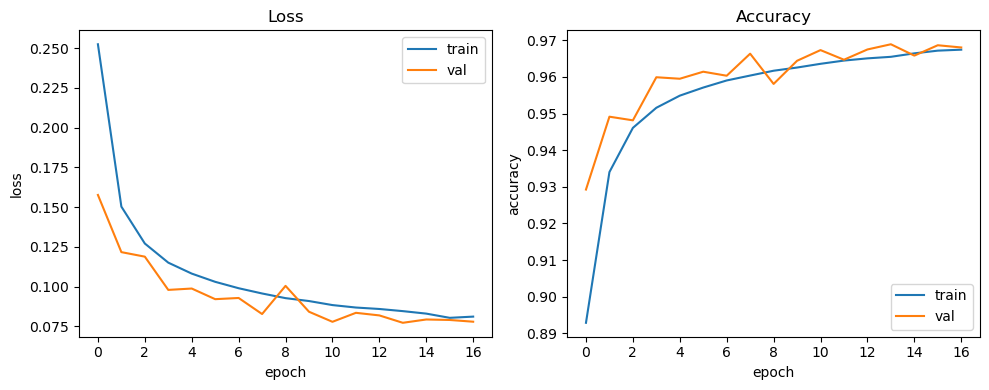

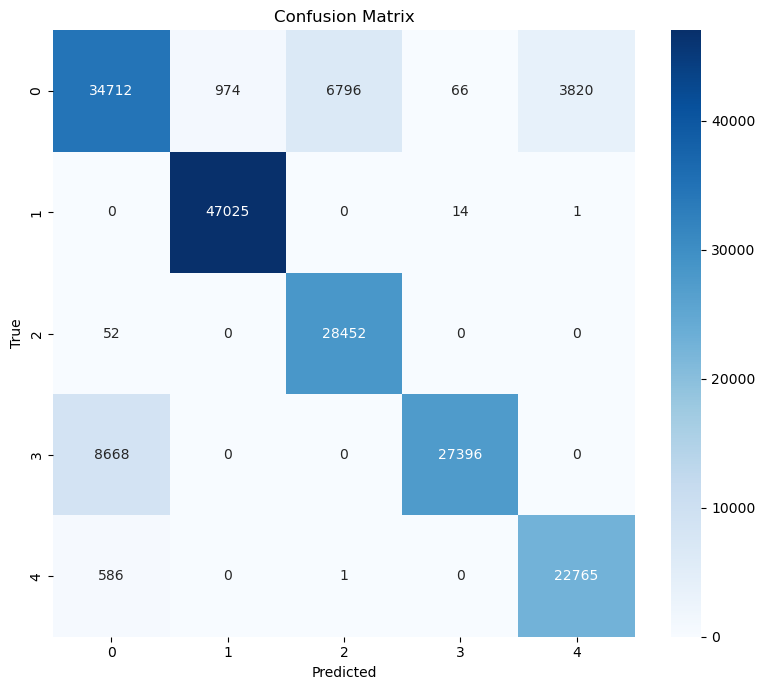

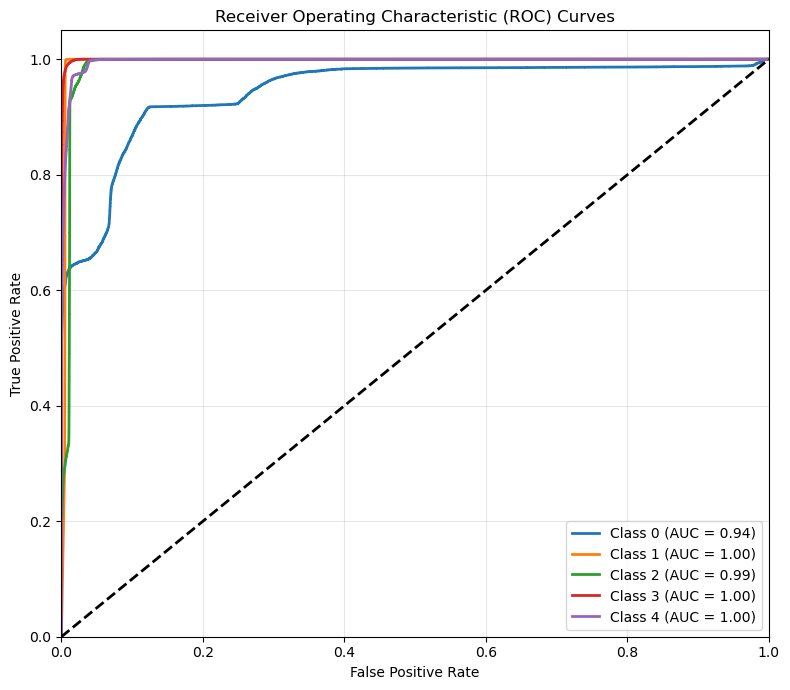

<Figure size 1000x500 with 0 Axes>

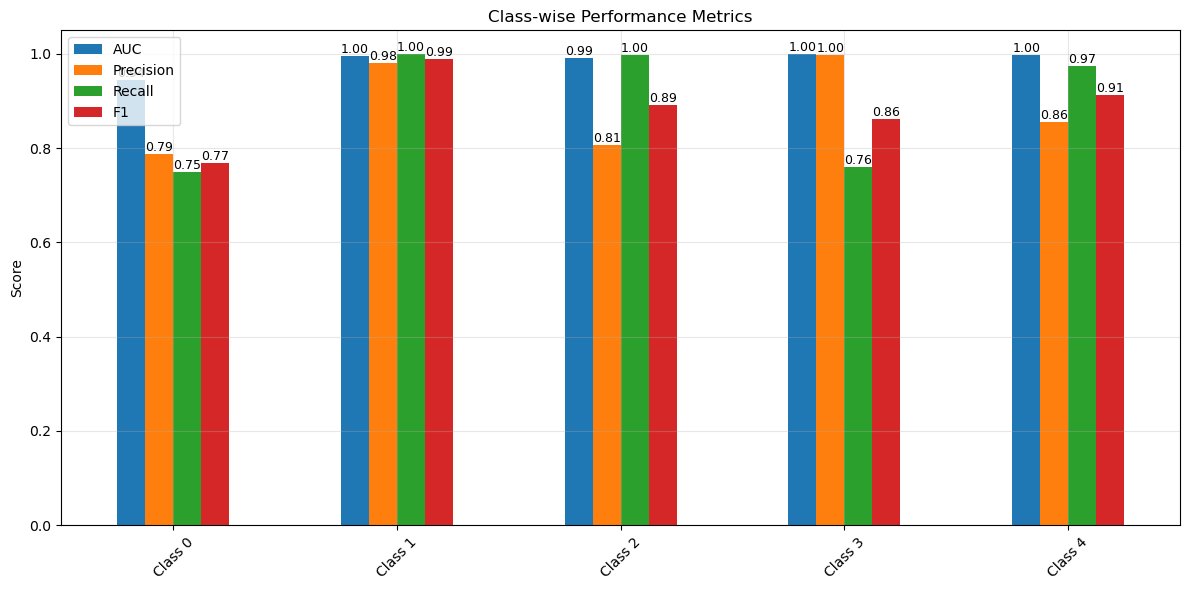

결과가 c:\Users\awear\my_projects\deep_learning\checkpoints 디렉토리에 저장되었습니다.


In [ ]:
tr_loss, tr_acc = zip(*hist_train)
va_loss, va_acc = zip(*hist_val)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(tr_loss, label='train'); plt.plot(va_loss, label='val')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.title('Loss'); plt.legend()
plt.subplot(1,2,2)
plt.plot(tr_acc, label='train'); plt.plot(va_acc, label='val')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.title('Accuracy'); plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "learning_curves.png"))
plt.show()

# Confusion matrix
plt.figure(figsize=(8,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "confusion_matrix.png"))
plt.show()

# ROC curves
truth_bin = label_binarize(all_labels, classes=np.arange(num_classes))
plt.figure(figsize=(8,7))
auc_values = []

for c in range(num_classes):
    fpr, tpr, _ = roc_curve(truth_bin[:,c], all_probs[:,c])
    roc_auc = auc(fpr, tpr)
    auc_values.append(roc_auc)
    plt.plot(fpr, tpr, lw=2, label=f'Class {c} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "roc_curves.png"))
plt.show()

# Class-wise performance summary
plt.figure(figsize=(10,5))
class_metrics = {
    'AUC': auc_values,
    'Precision': precision_score(all_labels, all_preds, average=None),
    'Recall': recall_score(all_labels, all_preds, average=None),
    'F1': f1_score(all_labels, all_preds, average=None)
}

metrics_df = pd.DataFrame(class_metrics, index=[f'Class {i}' for i in range(num_classes)])
ax = metrics_df.plot(kind='bar', figsize=(12,6))
plt.title('Class-wise Performance Metrics')
plt.ylabel('Score')
plt.ylim([0, 1.05])
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Add text annotations
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, "class_metrics.png"))
plt.show()

# Save summary information
# Extract only serializable elements
summary = {
    'accuracy': float(test_acc),
    'f1_weighted': float(f1),
    'precision_weighted': float(precision), 
    'recall_weighted': float(recall),
    'class_wise_auc': [float(v) for v in auc_values],
    'model_path': MODEL_PATH,
    'dataset_info': {
        'train_samples': len(train_ds),
        'val_samples': len(val_ds),
        'test_samples': len(test_ds),
        'num_classes': num_classes
    },
    # Extract only useful scalar information from checkpoint
    'checkpoint_info': {
        'epoch': int(checkpoint.get('epoch', -1)),
        'train_loss': float(checkpoint.get('train_loss', 0)),
        'val_loss': float(checkpoint.get('val_loss', 0)),
        'train_acc': float(checkpoint.get('train_acc', 0)),
        'val_acc': float(checkpoint.get('val_acc', 0))
    }
}


import json
with open(os.path.join(CHECKPOINT_DIR, 'results_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print(f"결과가 {CHECKPOINT_DIR} 디렉토리에 저장되었습니다.")